# TEST CAA - QUANTITATIVE RESEARCHER ROLE

The traditional way of building an investment portfolio is a two-step process that separates parameter estimation from optimization: 
- First, expected returns and dependence relationships (covariances) between assets are estimated.
- Second, these estimates are plugged into a mathematical model, to find the optimal mix of assets accordingly to the objective. 

The main issue with this “estimate-then-optimize” approach is that both steps are treated as separate tasks, leading to several issues, in particular with multivariate time series data: 
- First, estimation errors get magnified during the optimization process. 
- Second, the method focuses on the wrong goal – creating the best statistical model, rather than finding the parameters that will lead to the best decision in the future. 
- Third, it gets trickier as dimensions (e.g. portfolio assets) increase. Accurately estimating how hundreds or thousands of assets will interact with each other (a high-dimensional problem) is incredibly difficult and statistically fragile. State-of-the-art methods require a huge amount of effort to get this estimation right, which remains a major hurdle.

Machine Learning applies in portfolio management in two main ways. 
- The first approach involves forecasting, where models predict stock movements to inform a rule-based system. 
- The second approach uses Reinforcement Learning (RL), where an agent directly learns to execute actions (buy, sell, hold) by optimizing for long-term rewards, making it ideal for scenarios where the final outcome is only known at the end of a trading period.

**This notebook objective is to develop of policy (strategy) for building a portfolio. The portfolio is essentially an allocation of available resources across various assets. The policy then needs to restructure the portfolio over time as new information becomes available.**

In simple terms: **Given histories of 3 different assets (equities, bonds and gold), how would you allocate a fixed amount of money between these stocks every day that maximize the likelihood of returns.**

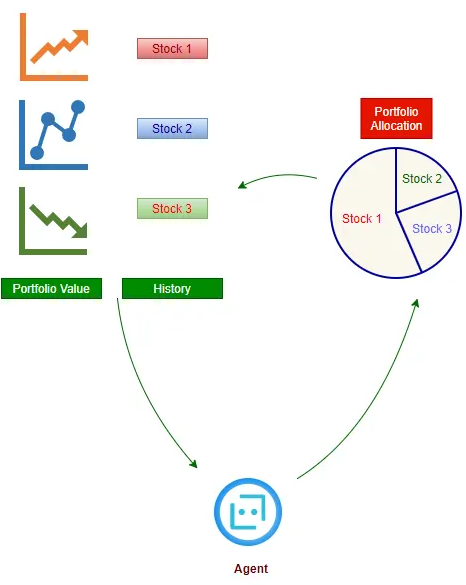

**Your role**: Develop a reinforcement learning model — an agent that allocates stocks at every time step by observing the indicators for each stock. In more details, your goal is to design an agent that interacts with a trading environment to maximize portfolio value. In this setup, each day should represent the agent's decision on asset allocation (e.g., 30% equities, 30% bonds, 30% gold). Based on the performance of this allocation, the agent receives a positive or negative reward. Through iterative learning, the agent refines its strategy to identify the optimal asset allocation for any given market state. Ultimately, you can compare your RL policy with Markowitz’ efficient frontier approach as natural benchmark. Cherry on the cake : include transaction costs - 2 bps for bonds, 5 bps for stocks and 10 bps for gold (1 bp = 0.01%)

**Rules**: 
- From PPO to DPO, choose the RL approach that suits best accordingly to the objective from your point of view.
- Please defend and motivate your choices.
- Be short and clear

**Data**: Attached dataset contains the daily returns from 4th of January, 1999 until 30th of September, 2025, for 3 assets 
- Equities (MSCI World Index, MXWD Index)
- Gold (XAU Curncy)
- Fixed-Income (Bloomberg Global Aggregate TR Index)

Only the attached data must be used in the context of the exercice.

**Première Étape : PRE-PROCESSING DES DONNÉES**

In [1]:
# Import libraries
import pandas as pd
import numpy as np

In [2]:
df = pd.read_excel('RL_toy_data.xlsx', index_col=0, parse_dates=True)
df = df.rename(columns={"Equities (MXWD Index)" : "Equities", "Gold (XAU Curncy)" : "Gold", "Fixed-Income (LEGATRUU Index)" : "Fixed-Income"}).astype(np.float32)
df

,Equities,Gold,Fixed-Income
Date,,,
1999-01-04,0.010318,-0.000174,0.000000
1999-01-05,0.010177,-0.002607,-0.001293
1999-01-06,0.018965,0.004705,-0.001274
1999-01-07,-0.002674,0.010579,-0.000987
1999-01-08,-0.001023,0.000000,-0.006108
...,...,...,...
2025-09-24,-0.002963,-0.007399,-0.003181
2025-09-25,-0.005862,0.003554,-0.003718
2025-09-26,0.003534,0.002811,0.000325


In [3]:
df.isna().sum() # Aucunes valeurs Manquantes
df.dtypes # FLoat est un bon format pour les opérations

Equities        float32
Gold            float32
Fixed-Income    float32
dtype: object

In [4]:
df.describe()

,Equities,Gold,Fixed-Income
count,6977.000000,6977.000000,6977.000000
mean,0.000232,0.000427,0.000119
std,0.009783,0.010486,0.003370
min,-0.095133,-0.090737,-0.021761
25%,-0.004118,-0.004695,-0.001789
50%,0.000566,0.000402,0.000075
75%,0.004967,0.005796,0.001989
max,0.093101,0.107883,0.028569


L'excel donné comporte donc les rendements, par rapport au jour précédent, de chaque actif. (Petite remarque mais l'or est, en moyenne, presque 2 fois plus rentables que les equities sur les 25 dernières années mais aussi un peu plus volatil (std).. )

Il est nécessaire de conserver les valeurs en rendements car l'environnement n'utilise que la valeur du portefeuille (qu'on initialisera arbitrairement).

Tout d'abord, un peu de bibliographie s'impose. Je vais consulter des papiers de recherche sur le thème de l'asset allocation avec le Reinforcement Learning. Cette recherche sur **l'état de l'art va me permettre de choisir l'algorithme le plus adapté au problème** : un problème d'asset allocation avec coûts de transaction.

L'état de l'art se situe probablement dans l'algorithme **PPO (Proximal Policy Optimisation)** d'après [1]. En effet, l'utilisation de PPO en (interday) est pertinente car elle répond au besoin de stabilité de l'allocation d'actifs sur le long terme. L'espace d'action étant continu (les poids du portefeuille), PPO est plus adapté que des méthodes basées sur la valeur (comme DQN).
De plus, son **mécanisme de clipping [2] évitant un shift des poids trop rapide entre 2 jours consécutifs** permet d'éviter que la "policy" devienne instable lors de changements de régime de marchés (et ainsi évite des couts transactionnels trop importants!!).

Pour ce qui est de l'architecture de cet algorithme, conscient de la limitation du nombre de données en interday (~6500 points), il est plus importnant d'utiliser une architecture neuronale simple (MLP peu profond) pour éviter l'overfitting, contrairement aux modèles profonds (CNN/LSTM).

On va pouvoir utiliser la bibliothèque Stable Baselines3 pour implémenter tout cela.


Sources :
[1] Deep Reinforcement Learning for Active High Frequency Trading, Briola, 2021
[2] Proximal Policy Optimization Algorithms, Schulman, 2017

**Deuxième Étape : CRÉATION DE LA CLASSE NÉCESSAIRE AU MODÈLE**

In [11]:
import stable_baselines3 as stb_b
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env

class PortfolioTrading(gym.Env):
    def __init__(self, df, initial_amount, fenetre_arrière):
        super().__init__()

        self.asset_names = df.columns.to_list()
        self.df = df
        self.n_assets = 3
        self.initial_portfolio_value = initial_amount # Valeur de notre Portefeuille en 1999 au départ
        self.lookback_window = fenetre_arrière
        self.transaction_costs = {"Gold" : 0.0010,"Fixed-Income" : 0.0002, "Equities" : 0.0005 }

        # On crée le vecteurs des poids pour l'agent :
        self.action_space = spaces.Box(low=0, high=1 , shape=( self.n_assets,), dtype=np.float32) # On crée un vecteur continu, normalisé par l'agent

        # On précise la shape de notre État S(t) : 
        # On a dimension = (Nombre d'actifs * Longueur de la fenêtre) + Nombre d'actifs (pour l'allocation précédente)
        obs_dim = (self.n_assets * self.lookback_window) + self.n_assets
        self.observation_space = spaces.Box(low =-np.inf, high= np.inf, shape=(obs_dim,), dtype=np.float32)

        # Variables pour le suivi RL :
        self.current_step = self.lookback_window  #Représente le jour (l'indice) dans votre DataFrame de données où se trouve l'agent actuellement
        self.portfolio_value = initial_amount

        self.previous_weights = np.array([1/self.n_assets] * self.n_assets) # on suppose que, au départ on a une équidistribution


    def _get_obs(self): # Construit l'état S(t) pour l'agent

        R_hist = self.df.iloc[self.current_step - self.lookback_window : self.current_step].values.flatten()
        Observation = np.concatenate([R_hist, self.previous_weights])
        return Observation
    
    def reset(self, *, seed = None, options = None):

        super().reset(seed=seed, options=options)
        self.portfolio_value = self.initial_portfolio_value
        self.previous_weights = np.array([1/self.n_assets] * self.n_assets, dtype=np.float32)
        self.current_step = self.lookback_window

        # Création du premier état
        observation = self._get_obs()
        info = {'Portfolio_value': self.portfolio_value}
        return observation, info
    
    def step(self, action):

        # Normalisation des poids et l'on empeche la division par 0 (qui a peu de chance d'arriver mais tout de même)
        current_weights = np.clip(action, 0,1) 
        weights_sum = np.sum(current_weights)
        if weights_sum ==0 :
            norm_weights = self.previous_weights
        else :
            norm_weights = current_weights / weights_sum
        
        today_return = self.df.iloc[self.current_step].values
        # Return sans couts de transaction 
        Return = np.dot(norm_weights, today_return)
        # Calcul des coûts de transaction 
        weight_shift = np.abs(norm_weights - self.previous_weights)
        cost_rate = np.array([self.transaction_costs[asset] for asset in self.asset_names])
        Trans_costs = np.dot(weight_shift, cost_rate) * self.portfolio_value # Taux de coûts de transaction * Valeur du portefeuille
        # Calcul de la Valeur du portefeuille :
        value_yesterday = self.portfolio_value
        self.portfolio_value = self.portfolio_value *(1 + Return) - Trans_costs
        #Définition d'un Reward assez simple :
        Reward = np.log(self.portfolio_value / value_yesterday)
        #Pour la prochaine étape :
        self.current_step += 1
        self.previous_weights = norm_weights

        new_observation = self._get_obs()
        info = {'Portfolio_value': self.portfolio_value, 'portfolio_return': Return, 'cost_value': Trans_costs}

        terminated = self.current_step >= len(self.df) - 1 # teste si on arrive à la fin du dataset
        truncated = False
    
        return new_observation, Reward, terminated, truncated, info

**Troisième Étape : IMPLEMENTATION DU MODÈLE PPO :**

In [46]:
Split = int(0.8 *len(df))
df.index[Split]

Timestamp('2020-05-26 00:00:00')

In [47]:
#Séparation entrainement/test :

SPLIT_DATE = '2020-05-26'
df_train = df.loc[df.index <= SPLIT_DATE].copy().astype(np.float32)
df_test = df.loc[df.index > SPLIT_DATE].copy().astype(np.float32)

env_train = PortfolioTrading(df_train, initial_amount=10000, fenetre_arrière=10)

env_test = PortfolioTrading(df_test, initial_amount=10000, fenetre_arrière=10)

days_per_episode = len(df_train)
n_epochs = 10                     # Nombre de fois où on re-parcourt l'histoire
Timesteps_total = days_per_episode * n_epochs

model = PPO("MlpPolicy",
            env_train, verbose=1, 
            learning_rate=0.0003,
            n_steps=256,        # Nombre d'étapes d'environnement avant la mise à jour
            batch_size=64)       # Taille du batch pour l'optimisation

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


On entraine sur 80 % du dataset on prédit sur les 20 % restants.

In [48]:
model.learn(total_timesteps=Timesteps_total)

-----------------------------
| time/              |      |
|    fps             | 2172 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 256  |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 1455         |
|    iterations           | 2            |
|    time_elapsed         | 0            |
|    total_timesteps      | 512          |
| train/                  |              |
|    approx_kl            | 0.0016290525 |
|    clip_fraction        | 0.00156      |
|    clip_range           | 0.2          |
|    entropy_loss         | -4.26        |
|    explained_variance   | -10          |
|    learning_rate        | 0.0003       |
|    loss                 | -0.0101      |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.00531     |
|    std                  | 1            |
|    value_loss           | 0.000594     |
----------------

In [50]:
def evaluate_policy(model, env, initial_capital):
    obs, info = env.reset()
    done = False
    net_worth_history = [initial_capital]
    
    while not done:
        action, _states = model.predict(obs, deterministic=True)  # agent donne la meilleure décision possible
        
        # Action
        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated # Convention Gymnasium..
        
        # Sauvegarde de la valeur du portefeuille
        net_worth_history.append(info['Portfolio_value'])

    final_value = env.portfolio_value
    total_return = (final_value / initial_capital) - 1
    
    return final_value, total_return, net_worth_history

final_value, total_return, history = evaluate_policy(model, env_test, initial_capital=10000)

initial_capital = 10000
print(f"Valeur Initiale : {initial_capital:,.2f} $")
print(f"Valeur Finale : {final_value:,.2f} $")
print(f"Rendement Total Net : {total_return * 100:.2f} %")

Valeur Initiale : 10,000.00 $
Valeur Finale : 22,328.92 $
Rendement Total Net : 123.29 %


On peut observer l'évolution de notre capital prédit par PPO à partir de 2020 :

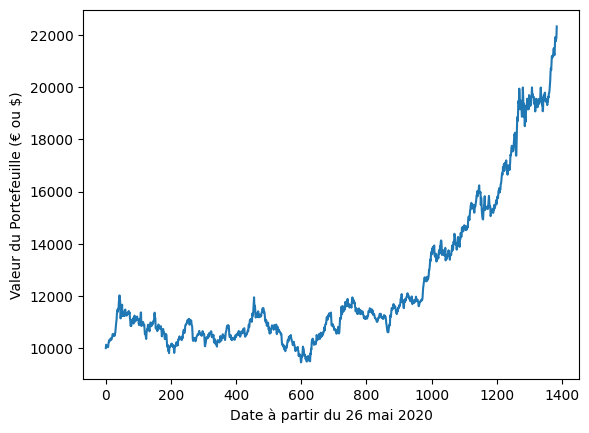

In [58]:
import matplotlib.pyplot as plt
T = np.arange(0, len(history))
plt.plot(T, history)
plt.xlabel('Date à partir du 26 mai 2020')
plt.ylabel('Valeur du Portefeuille (€ ou $)')
plt.show()

**Dernière Étape : COMPARAISON AVEC LA FRONTIÈRE EFFICIENTE DE MARKOWITZ**

In [ ]:
df_bench = df.copy()
T = 252 # On suppose qu'il y a 252 jours de trading par an

## Calcul pour Markowitz
mean_daily_returns = df_bench.mean()
cov_daily = df_bench.cov()
annual_returns = mean_daily_returns * T # matrice de rendements moyens annualisés
annual_cov = cov_daily * T # matrice de cov annualisée

## Calcul pour PPO :
ppo_daily_returns = pd.Series(history).pct_change().dropna() # On transforme history en 
ppo_annual_return = ppo_daily_returns.mean() * T
ppo_annual_volatility = ppo_daily_returns.std() * np.sqrt(T)
ppo_sharpe_ratio = ppo_annual_return / ppo_annual_volatility


Rendement Annualisé PPO : 15.76%
Volatilité Annualisée PPO : 15.00%
Ratio de Sharpe PPO : 1.05


On génère 10000 portefeuilles avec poids aléatoires afin de visualiser la frontière de Markowitz :

In [62]:
num_assets = len(annual_returns)
num_portfolios = 10000

results = np.zeros((3, num_portfolios)) # Va stocker rendement, volatilité et ratio sharpe
for i in range(num_portfolios):
    # Génération de poids randoms normalisés
    weights = np.random.random(num_assets)
    weights /= np.sum(weights)

    Return = np.dot(weights, annual_returns) # rendement annualisé avec les poids randoms

    Volatility = np.sqrt(np.dot(weights.T, np.dot(annual_cov, weights))) # volatilité annualisée 

    sharpe_ratio = Return / Volatility # calcul de sharpe 

    results[0, i] = Volatility
    results[1, i] = Return
    results[2, i] = sharpe_ratio

results_frame = pd.DataFrame(results.T, columns=['Volatilité', 'Rendement', 'Ratio_Sharpe'])

## Portefeuille au risque minimal
min_vol_index = results_frame['Volatilité'].idxmin()
mvp = results_frame.iloc[min_vol_index]
## Portefeuille au Ratio sharpe Maximal (le meilleur selon Markowitz) :
max_sharpe_index = results_frame['Ratio_Sharpe'].idxmax()
msr = results_frame.iloc[max_sharpe_index]

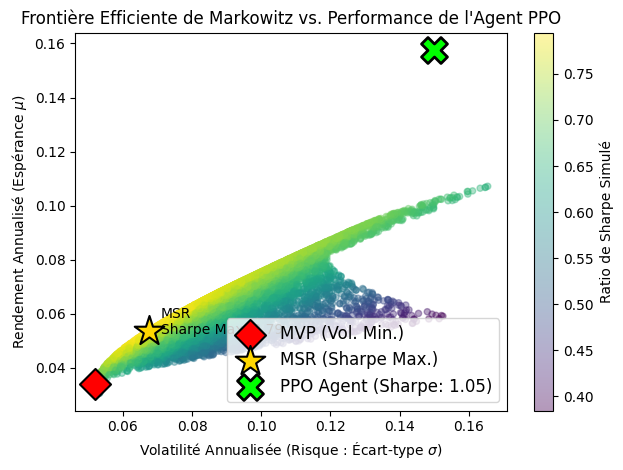

1. MARKOWITZ MSR (Théorie - Optimal) :
   Rendement Annualisé : 5.37%
   Volatilité Annualisée : 6.76%
   Ratio de Sharpe Max : 0.79

2. AGENT PPO (Apprentissage) :
   Rendement Annualisé : 15.76%
   Volatilité Annualisée : 15.00%
   Ratio de Sharpe PPO : 1.05


In [78]:
# Tracé des portefeuilles simulés et des MSR/MVP POUR MARKOWITZ
scatter = plt.scatter(results_frame['Volatilité'], results_frame['Rendement'], c=results_frame['Ratio_Sharpe'], cmap='viridis', alpha=0.4, s=20)
plt.colorbar(scatter, label='Ratio de Sharpe Simulé')

plt.scatter(mvp['Volatilité'], mvp['Rendement'],marker='D', color='red', s=250, label='MVP (Vol. Min.)', edgecolors='black', linewidth=1.5)

plt.scatter(msr['Volatilité'], msr['Rendement'],marker='*', color='gold', s=500, label='MSR (Sharpe Max.)', edgecolors='black', linewidth=1.5)

# Tracé pour PPO :
plt.scatter(ppo_annual_volatility, ppo_annual_return,marker='X', color='lime', s=350, label=f'PPO Agent (Sharpe: {ppo_sharpe_ratio:.2f})', edgecolors='black', linewidth=2)

# Mise en forme
plt.title('Frontière Efficiente de Markowitz vs. Performance de l\'Agent PPO')
plt.xlabel('Volatilité Annualisée (Risque : Écart-type $\\sigma$)')
plt.ylabel('Rendement Annualisé (Espérance $\\mu$)')

plt.annotate(
    f"MSR\nSharpe Max: {msr['Ratio_Sharpe']:.2f}",
    xy=(msr['Volatilité'], msr['Rendement']),
    xytext=(msr['Volatilité'] * 1.05, msr['Rendement'] * 0.98),
)
plt.legend(fontsize=12, loc='lower right')
plt.tight_layout()
plt.show()

# Markowitz MSR
print("1. MARKOWITZ MSR (Théorie - Optimal) :")
print(f"   Rendement Annualisé : {msr['Rendement']:.2%}")
print(f"   Volatilité Annualisée : {msr['Volatilité']:.2%}")
print(f"   Ratio de Sharpe Max : {msr['Ratio_Sharpe']:.2f}")

# PPO Agent
print("\n2. AGENT PPO (Apprentissage) :")
print(f"   Rendement Annualisé : {ppo_annual_return:.2%}")
print(f"   Volatilité Annualisée : {ppo_annual_volatility:.2%}")
print(f"   Ratio de Sharpe PPO : {ppo_sharpe_ratio:.2f}")

**Conclusion :**
On remarque que l'algorithme PPO a de très bonnes performances. Il surpasse de trois fois le rendement annualisé du MSR et possède un ratio de sharpe bien plus élevé que le MSR. Toutefois, il semble "prendre" plus de risques dans les choix de portefeuille mais ce risque est "justifié" par un ratio de sharpe meilleur ! 